# Initial Modeling Results

This notebook only **loads and displays saved results**. It trains nothing, evaluates nothing and imports no modeling library.

**Stage 1: Initial Modeling** - Historical Median Baseline, Initial XGBoost, Initial CatBoost, Initial MLP (sections 1-6).
**Stage 2: Hyperparameter Tuning** (section 7): earlier exploration (7.1), seeded hyperparameter search for XGBoost / CatBoost / MLP, two-model stacking, Validation 2024 comparison, final selection, one Test 2025 evaluation of the frozen selection, and feature importance (7.2-7.9).

Models were trained on natural `ln(price)` and converted back with `exp` (not `expm1`). **MAE (SAR) is the primary metric; R² on the original SAR scale is the main R²; R² on `ln(price)` is a supporting diagnostic** (empty where it was never computed).

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, Markdown, display

# Locate the repository root from any working directory (this notebook lives in notebooks/).
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'src').is_dir() and (p / 'requirements.txt').exists())
INIT = ROOT / 'outputs' / 'initial_models'
TUNE = ROOT / 'outputs' / 'tuning'
TABLES, FIGS = INIT / 'tables', INIT / 'figures'
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 30)

val = pd.read_csv(TABLES / 'initial_validation_comparison.csv')
test = pd.read_csv(TABLES / 'initial_test_comparison.csv')
per_type = pd.read_csv(TABLES / 'initial_per_property_type_test_metrics.csv')
fit = pd.read_csv(TABLES / 'initial_overfitting_check.csv')
history = pd.read_csv(TABLES / 'mlp_training_history.csv')
summary = json.loads((TABLES / 'model_selection_summary.json').read_text(encoding='utf-8'))
frozen = json.loads((INIT / 'models/frozen_configs.json').read_text(encoding='utf-8'))
legacy = {'XGBoost': 'Initial XGBoost', 'CatBoost': 'Initial CatBoost', 'MLP': 'Initial MLP'}   # names in older saved files
fit['Model'] = fit['Model'].replace(legacy)
print('Loaded saved results. Initial models frozen at (UTC):', frozen['frozen_at_utc'])

Loaded saved results. Initial models frozen at (UTC): 2026-09-19T06:47:32+00:00


## 1. Validation 2024 comparison (Initial Modeling)
Improvement = (baseline MAE - model MAE) / baseline MAE x 100.

In [2]:
val.drop(columns='Iteration detail')

,Model,Version,Rank (Validation MAE),Validation MAE (SAR),Validation RMSE (SAR),Validation R2 (SAR),Validation R2 (ln price),Median abs error (SAR),Training time (s),Best iteration / epochs,MAE improvement vs baseline (%),Met 15% target
0,Historical Median Baseline,Baseline,NaN,"663,987.7445","8,648,982.0274",0.0619,0.5551,"170,000.0000",0.2522,NaN,0.0000,n/a (reference)
1,Initial XGBoost,Initial,1.0000,"539,630.0420","8,261,631.7250",0.1440,0.7132,"117,989.8532",43.9214,"1,229.0000",18.7289,Yes
2,Initial CatBoost,Initial,2.0000,"554,411.0805","7,638,328.8945",0.2683,0.7019,"130,865.1861",437.2944,986.0000,16.5028,Yes
3,Initial MLP,Initial,3.0000,"977,812.5063","24,512,976.0190",-6.5355,0.3667,"210,436.5965",34.0810,13.0000,-47.2636,No


In [3]:
lines = []
for _, r in val.iloc[1:].sort_values('Validation MAE (SAR)').iterrows():
    verdict = 'meets' if r['Met 15% target'] == 'Yes' else 'does not meet'
    lines.append(f"- **{r['Model']}** (rank {int(r['Rank (Validation MAE)'])}): MAE {r['Validation MAE (SAR)']:,.0f} SAR, "
                 f"{r['MAE improvement vs baseline (%)']:.1f}% vs baseline, so it **{verdict}** the 15% target; "
                 f"R\u00b2 (SAR) {r['Validation R2 (SAR)']:.3f}; training time {r['Training time (s)']:.0f}s ({r['Iteration detail']}).")
display(Markdown('\n'.join(lines)))

- **Initial XGBoost** (rank 1): MAE 539,630 SAR, 18.7% vs baseline, so it **meets** the 15% target; R² (SAR) 0.144; training time 44s (1229 trees kept (early stopping)).
- **Initial CatBoost** (rank 2): MAE 554,411 SAR, 16.5% vs baseline, so it **meets** the 15% target; R² (SAR) 0.268; training time 437s (986 trees kept (early stopping)).
- **Initial MLP** (rank 3): MAE 977,813 SAR, -47.3% vs baseline, so it **does not meet** the 15% target; R² (SAR) -6.536; training time 34s (13 epochs completed (best epoch 5, weights restored)).

### Train vs validation (SAR scale)

In [4]:
fit

,Model,Train MAE (SAR),Validation MAE (SAR),Validation/Train MAE ratio,Train R2,Validation R2
0,Initial XGBoost,"311,219.0615","539,630.0420",1.7339,0.6703,0.1440
1,Initial CatBoost,"351,976.6981","554,411.0805",1.5751,0.4238,0.2683
2,Initial MLP,"566,867.4956","977,812.5063",1.7249,-1.2049,-6.5355


## 2. Test 2025 comparison (Initial Modeling; each initial model evaluated once)

In [5]:
test.drop(columns='Iteration detail')

,Model,Version,Test MAE (SAR),Test RMSE (SAR),Test R2 (SAR),Test R2 (ln price),Median abs error (SAR),Training time (s),Best iteration / epochs,MAE improvement vs baseline (%),Met 15% target
0,Historical Median Baseline,Baseline,"679,495.9399","9,480,146.8916",0.0204,0.4822,"172,500.0000",0.3013,NaN,0.0000,n/a (reference)
1,Initial XGBoost,Initial — Untuned,"596,077.3127","12,670,755.7478",-0.7500,0.6497,"130,468.5570",43.9214,"1,229.0000",12.2765,No
2,Initial CatBoost,Initial — Untuned,"554,819.4782","7,609,559.6728",0.3688,0.6445,"132,480.2527",437.2944,986.0000,18.3484,Yes
3,Initial MLP,Initial — Untuned,"1,186,305.5068","29,871,336.0617",-8.7260,0.1837,"247,778.3303",34.0810,13.0000,-74.5861,No


In [6]:
models_t = test.iloc[1:]
best_val, best_test = legacy.get(summary['best_by_validation_mae'], summary['best_by_validation_mae']), legacy.get(summary['best_by_test_mae'], summary['best_by_test_mae'])
lines = [f"- Best initial model by **Validation** MAE: **{best_val}**.", f"- Best initial model by **Test** MAE: **{best_test}**."]
for _, r in models_t.iterrows():
    v = val.loc[val['Model'] == r['Model'], 'Validation MAE (SAR)'].iloc[0]
    lines.append(f"- {r['Model']}: test MAE {r['Test MAE (SAR)']:,.0f} vs validation MAE {v:,.0f} "
                 f"({(r['Test MAE (SAR)'] / v - 1) * 100:+.1f}%); {r['MAE improvement vs baseline (%)']:.1f}% vs test baseline "
                 f"-> 15% target {'met' if r['Met 15% target'] == 'Yes' else 'not met'}; test R\u00b2 (SAR) {r['Test R2 (SAR)']:.3f}.")
display(Markdown('\n'.join(lines)))

- Best initial model by **Validation** MAE: **Initial XGBoost**.
- Best initial model by **Test** MAE: **Initial CatBoost**.
- Initial XGBoost: test MAE 596,077 vs validation MAE 539,630 (+10.5%); 12.3% vs test baseline -> 15% target not met; test R² (SAR) -0.750.
- Initial CatBoost: test MAE 554,819 vs validation MAE 554,411 (+0.1%); 18.3% vs test baseline -> 15% target met; test R² (SAR) 0.369.
- Initial MLP: test MAE 1,186,306 vs validation MAE 977,813 (+21.3%); -74.6% vs test baseline -> 15% target not met; test R² (SAR) -8.726.

## 3. Comparison plots (initial-model figures)

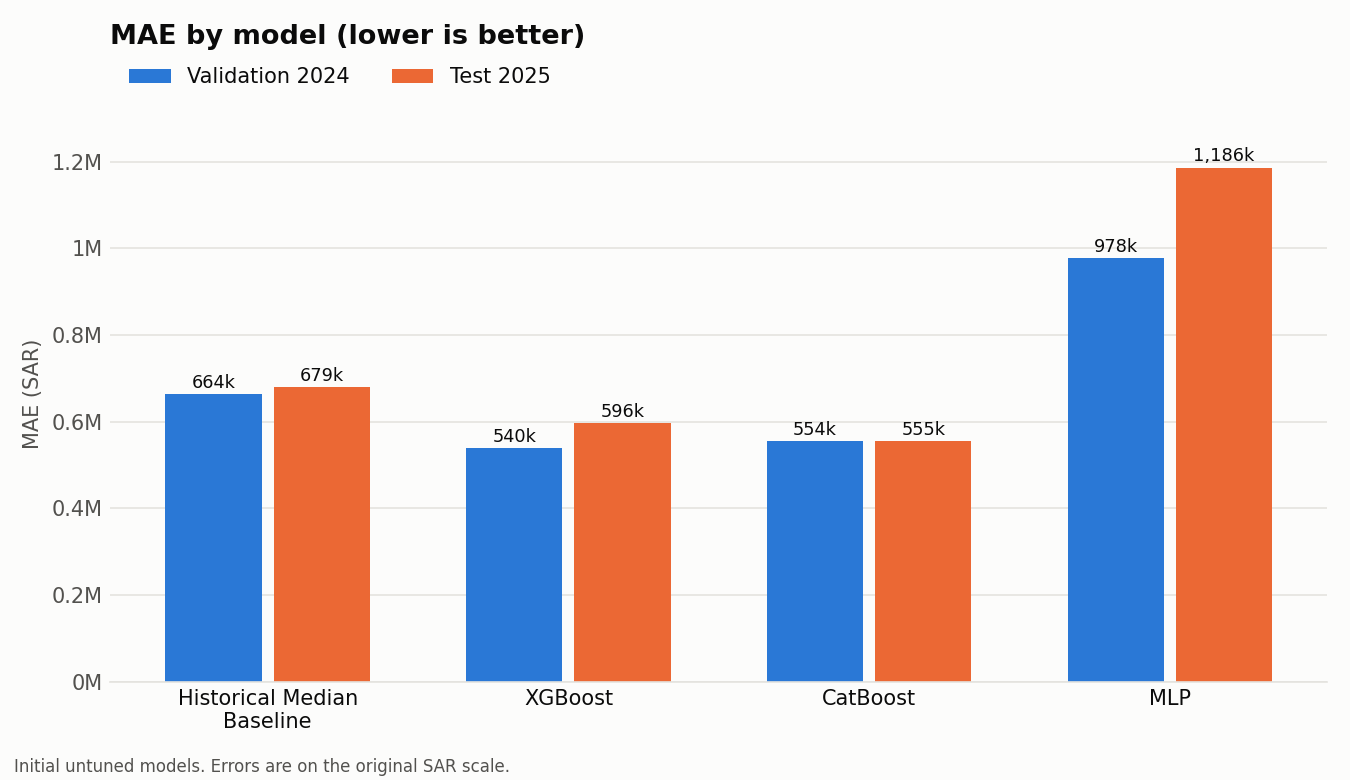

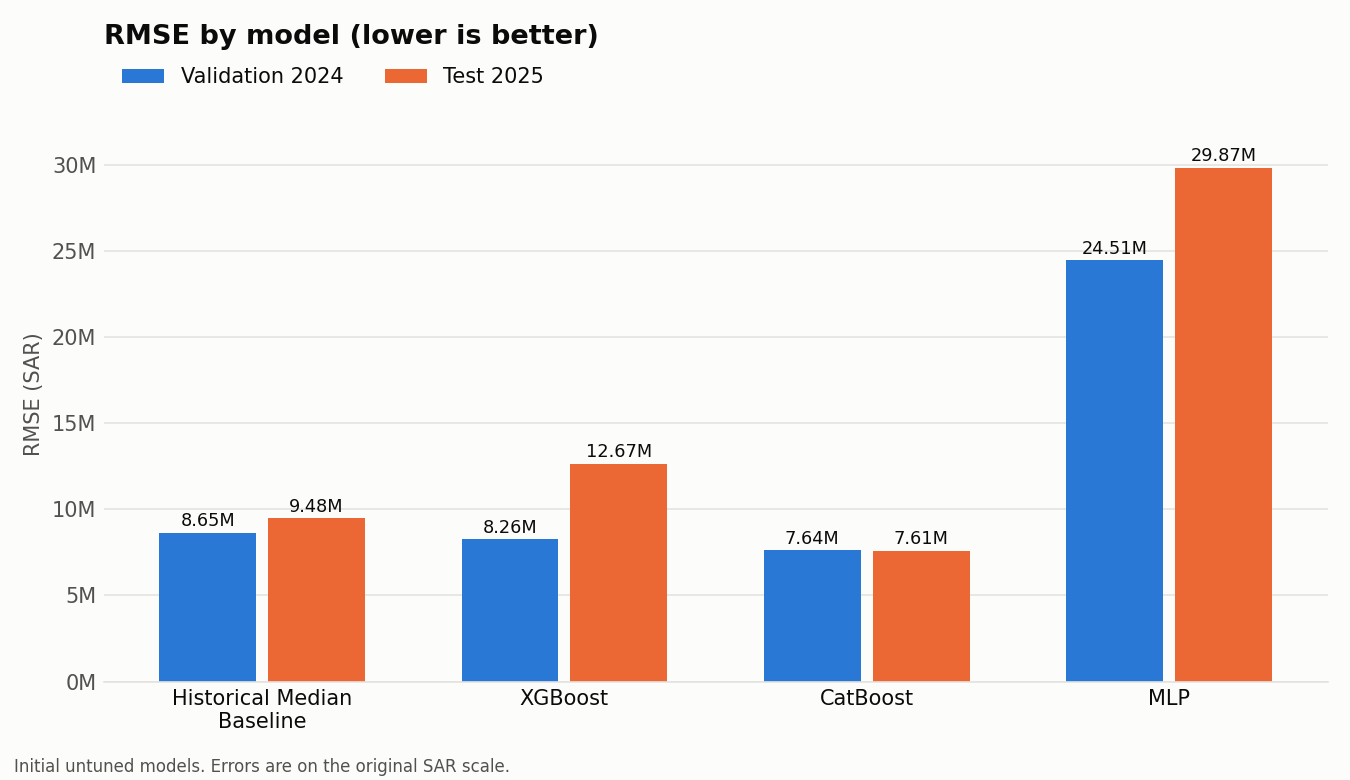

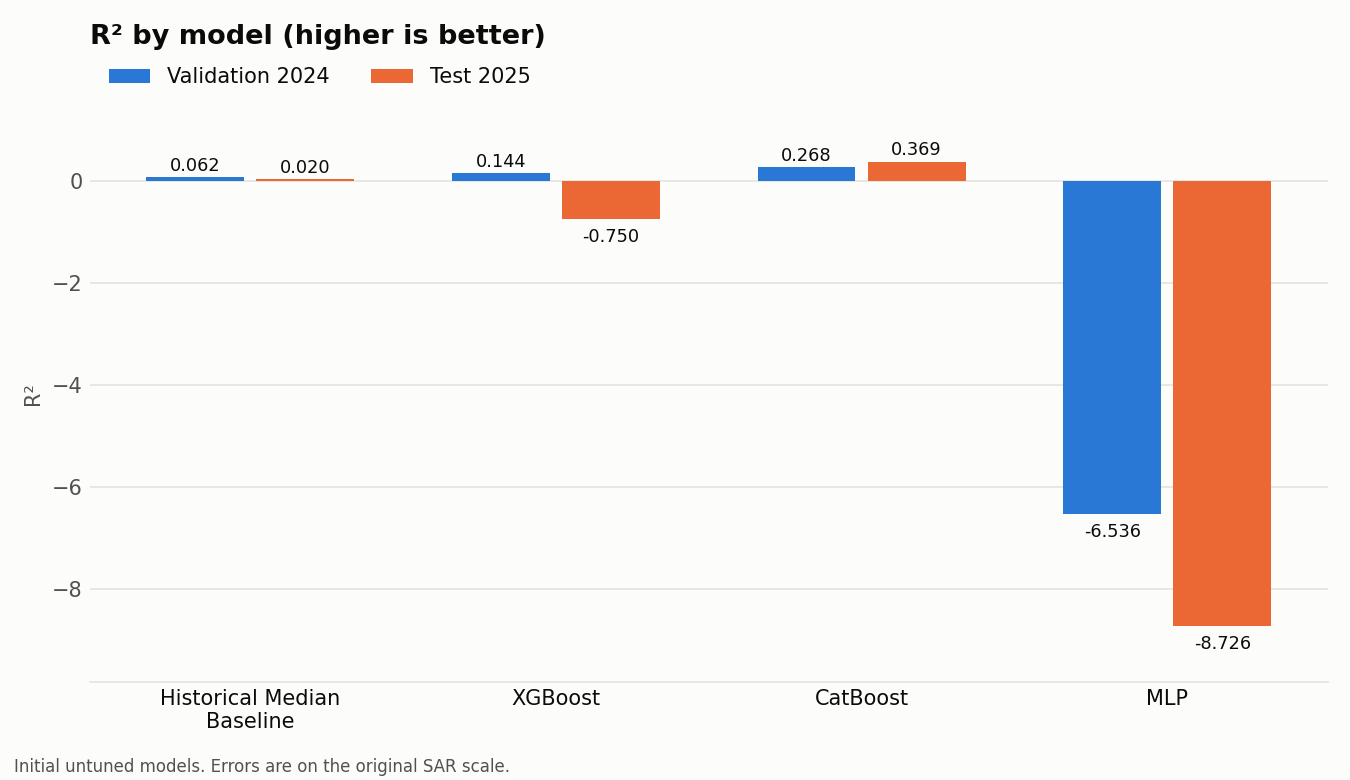

In [7]:
for name in ['model_comparison_mae', 'model_comparison_rmse', 'model_comparison_r2']:
    display(Image(filename=str(FIGS / f'{name}.png'), width=760))

## 4. Test results by property type

In [8]:
per_type.drop(columns='R2 note')

,Model,Property type,Test rows,MAE (SAR),RMSE (SAR),R2
0,Historical Median Baseline,Residential,181503,"480,021.6273","5,258,114.1396",0.0055
1,Historical Median Baseline,Commercial,12180,"3,231,369.4436","31,822,427.5326",0.0207
2,Historical Median Baseline,Agricultural,6255,"1,498,579.3729","9,928,843.1205",-0.0699
3,Initial XGBoost,Residential,181503,"381,752.4064","4,612,771.1756",0.2346
4,Initial XGBoost,Commercial,12180,"3,363,115.8200","47,703,108.0357",-1.2005
5,Initial XGBoost,Agricultural,6255,"1,427,106.0025","9,126,990.6689",0.0960
6,Initial CatBoost,Residential,181503,"388,363.7656","4,602,816.8419",0.2379
7,Initial CatBoost,Commercial,12180,"2,702,117.0510","24,344,781.2554",0.4269
8,Initial CatBoost,Agricultural,6255,"1,203,600.7367","9,060,417.0496",0.1091
9,Initial MLP,Residential,181503,"608,050.8995","10,611,073.1659",-3.0501


In [9]:
notes = per_type[per_type['R2 note'].notna()][['Model', 'Property type', 'R2 note']]
if len(notes):
    display(notes)
else:
    display(Markdown('R\u00b2 was defined and based on at least 30 rows for every model and property type.'))
only_models = per_type[per_type['Model'] != 'Historical Median Baseline']
best = only_models.loc[only_models.groupby('Property type')['MAE (SAR)'].idxmin()]
display(Markdown('Lowest test MAE per property type (initial models only): ' + '; '.join(
    f"**{r['Property type']}** - {r['Model']} ({r['MAE (SAR)']:,.0f} SAR, n={r['Test rows']:,})" for _, r in best.iterrows())))

R² was defined and based on at least 30 rows for every model and property type.

Lowest test MAE per property type (initial models only): **Agricultural** - Initial CatBoost (1,203,601 SAR, n=6,255); **Commercial** - Initial CatBoost (2,702,117 SAR, n=12,180); **Residential** - Initial XGBoost (381,752 SAR, n=181,503)

## 5. Initial MLP training history

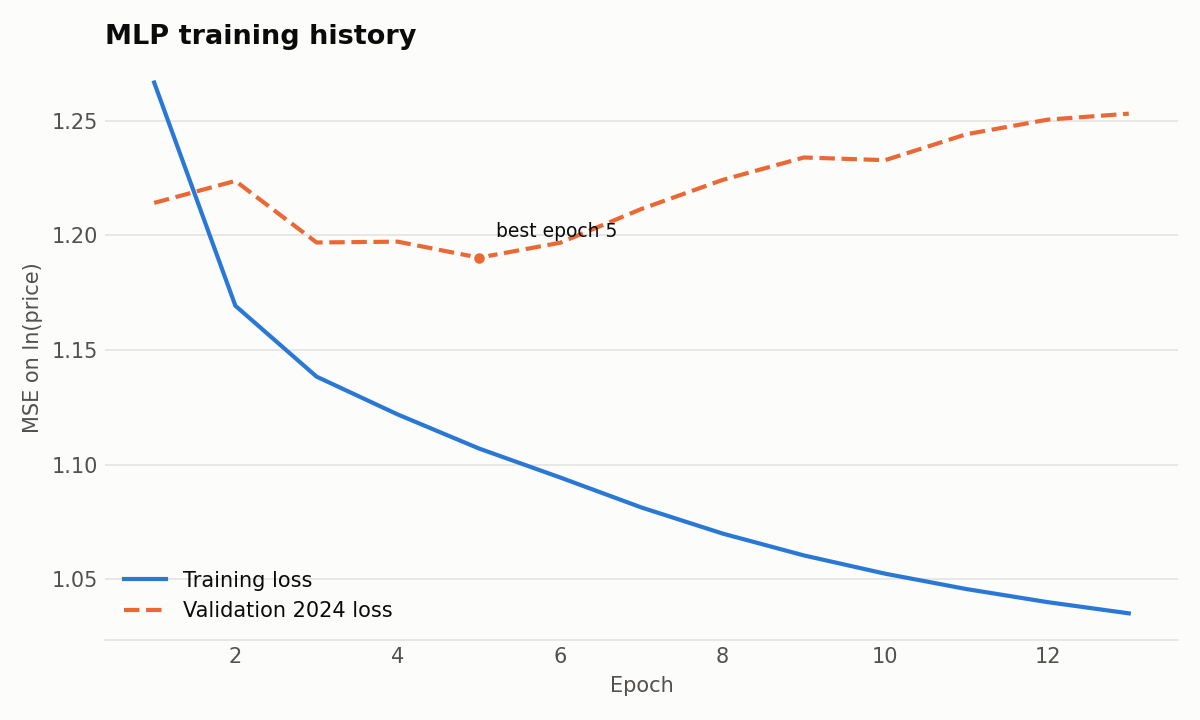

The Initial MLP ran **13 epochs** before early stopping; validation loss was lowest at epoch **5** and those weights were restored.

,epoch,loss,mae,val_loss,val_mae
0,1,1.2666,0.8547,1.2141,0.8232
1,2,1.1693,0.8158,1.2237,0.8282
2,3,1.1383,0.8040,1.1968,0.8130
3,4,1.1218,0.7972,1.1972,0.8132
4,5,1.1070,0.7915,1.1902,0.8118
5,6,1.0944,0.7865,1.1967,0.8212
6,7,1.0813,0.7816,1.2115,0.8340
7,8,1.0699,0.7771,1.2241,0.8406
8,9,1.0604,0.7733,1.2339,0.8452
9,10,1.0524,0.7700,1.2327,0.8459


In [10]:
display(Image(filename=str(FIGS / 'mlp_training_history.png'), width=640))
best_epoch = int(history.loc[history['val_loss'].idxmin(), 'epoch'])
display(Markdown(f"The Initial MLP ran **{len(history)} epochs** before early stopping; validation loss was lowest at epoch **{best_epoch}** and those weights were restored."))
history

## 6. Findings for Initial Modeling

In [11]:
v, t = val.set_index('Model'), test.set_index('Model')
cat, xgb_, mlp, base = 'Initial CatBoost', 'Initial XGBoost', 'Initial MLP', 'Historical Median Baseline'
drift = lambda m: (t.loc[m, 'Test MAE (SAR)'] / v.loc[m, 'Validation MAE (SAR)'] - 1) * 100
display(Markdown(f'''- **{cat}** has the lowest Test MAE ({t.loc[cat, 'Test MAE (SAR)']:,.0f} SAR) and the smallest validation-to-test MAE change ({drift(cat):+.1f}%), versus {drift(xgb_):+.1f}% for {xgb_}: it is the strongest stable individual initial model.
- **{mlp} performed worse than the baseline** in its current configuration (test MAE {t.loc[mlp, 'Test MAE (SAR)']:,.0f} vs {t.loc[base, 'Test MAE (SAR)']:,.0f} SAR). This is reported honestly and is not removed.
- SAR-scale R\u00b2 is strongly influenced by a small number of extreme Commercial transactions (see the Commercial rows in section 4). No outlier audit or data modification has been done.
- Recommended for later hyperparameter tuning (chosen by validation MAE only): {' and '.join(legacy.get(m, m) for m in summary['recommended_for_tuning'])}.
- Full report: `outputs/initial_models/reports/initial_models_report.md`.'''))

- **Initial CatBoost** has the lowest Test MAE (554,819 SAR) and the smallest validation-to-test MAE change (+0.1%), versus +10.5% for Initial XGBoost: it is the strongest stable individual initial model.
- **Initial MLP performed worse than the baseline** in its current configuration (test MAE 1,186,306 vs 679,496 SAR). This is reported honestly and is not removed.
- SAR-scale R² is strongly influenced by a small number of extreme Commercial transactions (see the Commercial rows in section 4). No outlier audit or data modification has been done.
- Recommended for later hyperparameter tuning (chosen by validation MAE only): Initial XGBoost and Initial CatBoost.
- Full report: `outputs/initial_models/reports/initial_models_report.md`.

## 7. Hyperparameter Tuning

### 7.1 Earlier exploration (kept unchanged)

The two tables below are the earlier tuning experiments (XGBoost `min_child_weight` trials and the fixed 50/50 ensemble), shown for reference. They are not initial models. Details: `outputs/tuning/reports/tuning_work_in_progress.md`.

**Test 2025 note:** Test 2025 was evaluated for the initial models and evaluated again for these experiments, so the tuning Test 2025 numbers are a *second look*, not an untouched holdout. Future tuning decisions must use Training 2020-2023 and Validation 2024 only.

In [12]:
pd.read_csv(TUNE / 'tables/v2_xgboost_validation_experiments.csv')

,min_child_weight,trees_kept,val_mae_sar,val_rmse_sar,val_r2_sar,val_r2_ln_price,train_seconds
0,50,1216,"531,508.8214","7,401,741.9131",0.3129,0.7118,43.2766
1,200,1406,"523,324.5082","7,198,782.9277",0.3501,0.7090,64.5286
2,1000,2684,"541,422.3431","7,646,554.3145",0.2667,0.6989,114.2356


In [13]:
display(Markdown('**Validation 2024 (tuning experiments; v1 rows are the initial models for reference)**'))
display(pd.read_csv(TUNE / 'tables/v2_validation_comparison.csv'))
display(Markdown('**Test 2025 (second look)**'))
display(pd.read_csv(TUNE / 'tables/v2_test_comparison.csv'))

**Validation 2024 (tuning experiments; v1 rows are the initial models for reference)**

,Model,Validation MAE (SAR),Validation RMSE (SAR),Validation R2 (SAR),Validation R2 (ln price),Median abs error (SAR),MAE improvement vs baseline (%)
0,XGBoost v1,"539,630.0420","8,261,631.7250",0.1440,0.7132,"117,989.8532",18.7289
1,CatBoost v1,"554,411.0805","7,638,328.8945",0.2683,0.7019,"130,865.1861",16.5028
2,XGBoost v2 (min_child_weight=200),"523,324.5082","7,198,782.9277",0.3501,0.7090,"118,440.1714",21.1846
3,"Ensemble v2 (XGBoost v2 + CatBoost, 50/50)","523,066.2696","6,801,708.3278",0.4198,0.7190,"119,562.6870",21.2235


**Test 2025 (second look)**

,Model,Test MAE (SAR),Test RMSE (SAR),Test R2 (SAR),Test R2 (ln price),Median abs error (SAR),MAE improvement vs test baseline (%),Met 15% target
0,XGBoost v1,"596,077.3127","12,670,755.7478",-0.7500,0.6497,"130,468.5570",12.2765,No
1,CatBoost v1,"554,819.4782","7,609,559.6728",0.3688,0.6445,"132,480.2527",18.3484,Yes
2,XGBoost v2 (min_child_weight=200),"561,275.7740","8,655,181.9514",0.1835,0.6488,"130,178.5244",17.3982,Yes
3,"Ensemble v2 (XGBoost v2 + CatBoost, 50/50)","545,025.9698","7,647,744.4402",0.3625,0.6604,"128,682.6028",19.7897,Yes


### 7.2 Hyperparameter search (XGBoost, CatBoost, MLP)

Seeded random search (code: `src/tuning/tune_models.py`). Every trial is fitted on Training 2020-2023 (features whose encodings/scaling were fitted on 2020-2023 only), early-stopped on Validation 2024 like the initial models, and scored by **Validation 2024 MAE in SAR** after `exp()` of the `ln(price)` prediction. Trial 0 re-runs each initial configuration (XGBoost trial 1 re-runs the earlier v2 setting). Test 2025 is not read by the search.

In [14]:
design = json.loads((TUNE / 'models/search_design.json').read_text(encoding='utf-8'))
spaces = pd.DataFrame([{'Model': m, 'Hyperparameter': k, 'Distribution': v[0], 'Range / options': v[1:]}
                       for m, sp in design['spaces'].items() for k, v in sp.items()])
display(Markdown(f"Seed `{design['seed']}`; random trials per model: {design['n_random_trials']}; "
                 f"fixed settings: {design['fixed_settings']}"))
spaces

Seed `42`; random trials per model: {'xgboost': 18, 'catboost': 9, 'mlp': 13}; fixed settings: {'xgboost': {'n_estimators': 5000, 'early_stopping_rounds': 50}, 'catboost': {'iterations': 3000, 'early_stopping_rounds': 50}, 'mlp': {'max_epochs': 60, 'early_stopping_patience': 8}}

,Model,Hyperparameter,Distribution,Range / options
0,xgboost,learning_rate,loguniform,"[0.03, 0.15]"
1,xgboost,max_depth,choice,"[[6, 7, 8, 9, 10, 12]]"
2,xgboost,min_child_weight,choice,"[[1, 5, 20, 50, 100, 200, 400, 800]]"
3,xgboost,subsample,uniform,"[0.6, 1.0]"
4,xgboost,colsample_bytree,uniform,"[0.6, 1.0]"
5,xgboost,reg_lambda,loguniform,"[0.1, 50.0]"
6,xgboost,reg_alpha,loguniform,"[0.001, 5.0]"
7,xgboost,gamma,choice,"[[0.0, 0.01, 0.05, 0.2]]"
8,catboost,learning_rate,loguniform,"[0.06, 0.25]"
9,catboost,depth,choice,"[[6, 7, 8, 9]]"


In [15]:
trials = {m: pd.read_csv(TUNE / f'tables/tuning_trials_{m}.csv') for m in ['xgboost', 'catboost', 'mlp']}
rows = []
for m, t in trials.items():
    s = json.loads((TUNE / f'status/{m}_tuned_validation_metrics.json').read_text(encoding='utf-8'))
    best = t.loc[t['val_mae_sar'].idxmin()]
    rows.append({'Model': m, 'Trials': len(t), 'Search time (min)': t['train_seconds'].sum() / 60,
                 'Trial 0 (initial) Val MAE': t.loc[t['trial'] == 0, 'val_mae_sar'].iloc[0],
                 'Best trial': int(best['trial']), 'Best Val MAE (SAR)': best['val_mae_sar'],
                 'Iterations kept': s['iteration_detail']})
pd.DataFrame(rows)

,Model,Trials,Search time (min),Trial 0 (initial) Val MAE,Best trial,Best Val MAE (SAR),Iterations kept
0,xgboost,20,21.2156,"539,630.0420",9,"518,148.7559",1295 trees kept (early stopping)
1,catboost,10,65.9784,"554,411.0805",2,"537,329.6287",851 trees kept (early stopping)
2,mlp,14,32.1399,"977,812.5063",2,"657,428.2776","18 epochs (best epoch, weights restored)"


In [16]:
for m in ['xgboost', 'catboost', 'mlp']:
    conf = json.loads((TUNE / f'models/{m}_tuned/{m}_tuned_config.json').read_text(encoding='utf-8'))
    display(Markdown(f"**Best {m} hyperparameters** (trial {conf['selected_trial']}, {conf['trial_source']}): "
                     + ', '.join(f'`{k}`={conf[k]}' for k in design['spaces'][m] if k in conf)))
    display(trials[m].drop(columns=['params_json']))

**Best xgboost hyperparameters** (trial 9, random search): `learning_rate`=0.04954, `max_depth`=12, `min_child_weight`=200, `subsample`=0.8187, `colsample_bytree`=0.6739, `reg_lambda`=41.39, `reg_alpha`=0.7365, `gamma`=0.01

,trial,source,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda,reg_alpha,gamma,iterations_used,val_mae_sar,val_rmse_sar,val_r2_sar,val_r2_ln_price,val_median_abs_error,train_seconds,val_predictions_clipped
0,0,initial config,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1229,"539,630.0420","8,261,631.7250",0.1440,0.7132,"117,989.8532",57.2909,0
1,1,earlier v2 setting,NaN,NaN,200.0000,NaN,NaN,NaN,NaN,NaN,1406,"523,324.5082","7,198,782.9277",0.3501,0.7090,"118,440.1714",70.3101,0
2,2,random search,0.0548,10.0000,400.0000,0.8928,0.8395,0.2637,0.0038,0.0500,1738,"519,459.5264","7,284,542.8098",0.3345,0.7127,"118,597.8312",105.7636,10
3,3,random search,0.0628,10.0000,50.0000,0.6571,0.8604,0.1420,0.4684,0.0100,708,"528,614.2106","7,666,260.8674",0.2630,0.7149,"118,604.4224",46.8488,0
4,4,random search,0.0422,9.0000,100.0000,0.8470,0.8447,0.1045,0.0012,0.0500,1625,"522,212.4237","7,369,323.7424",0.3190,0.7153,"116,976.6311",84.8798,0
5,5,random search,0.0803,7.0000,800.0000,0.7169,0.7465,1.7020,0.8023,0.0500,1201,"543,876.0894","7,824,310.5012",0.2323,0.6933,"124,928.2292",52.9680,29
6,6,random search,0.0555,9.0000,800.0000,0.7867,0.9440,6.8570,0.0464,0.0100,1393,"534,074.6033","7,644,282.8454",0.2672,0.7022,"122,221.6800",73.4572,14
7,7,random search,0.1382,9.0000,200.0000,0.9234,0.7218,0.1835,0.3396,0.0500,550,"527,960.2211","7,273,361.1996",0.3366,0.7100,"119,484.4842",42.0007,0
8,8,random search,0.0901,9.0000,100.0000,0.9333,0.6693,1.1360,0.0047,0.2000,1001,"526,729.5070","7,571,308.1175",0.2811,0.7132,"117,186.4732",46.4691,1
9,9,random search,0.0495,12.0000,200.0000,0.8187,0.6739,41.3900,0.7365,0.0100,1295,"518,148.7559","7,245,252.3270",0.3417,0.7158,"118,610.7736",65.6135,0


**Best catboost hyperparameters** (trial 2, random search): `learning_rate`=0.1552, `depth`=9, `l2_leaf_reg`=8.02, `random_strength`=1.485, `bagging_temperature`=0.2506, `one_hot_max_size`=16, `max_ctr_complexity`=2

,trial,source,learning_rate,depth,l2_leaf_reg,random_strength,bagging_temperature,one_hot_max_size,max_ctr_complexity,iterations_used,val_mae_sar,val_rmse_sar,val_r2_sar,val_r2_ln_price,val_median_abs_error,train_seconds,val_predictions_clipped
0,0,initial config,NaN,NaN,NaN,NaN,NaN,NaN,NaN,986,"554,411.0805","7,638,328.8945",0.2683,0.7019,"130,865.1861",516.5276,0
1,1,random search,0.0707,9.0000,1.4190,0.3904,0.1721,16.0000,4.0000,866,"544,192.5114","7,358,793.1269",0.3209,0.7039,"127,121.3048",398.5730,0
2,2,random search,0.1552,9.0000,8.0200,1.4850,0.2506,16.0000,2.0000,851,"537,329.6287","7,512,971.1222",0.2921,0.7089,"123,643.3150",344.8970,0
3,3,random search,0.0610,9.0000,1.2130,3.3530,0.2210,16.0000,1.0000,770,"560,880.1268","7,351,200.2249",0.3223,0.6782,"139,120.2764",363.6568,0
4,4,random search,0.0942,9.0000,4.1140,1.7680,0.6206,2.0000,1.0000,606,"558,316.9549","7,466,731.5939",0.3008,0.6800,"137,603.5973",365.7646,0
5,5,random search,0.2088,6.0000,4.5540,1.8590,0.0825,16.0000,1.0000,643,"580,115.3646","9,334,288.3495",-0.0927,0.6791,"139,016.9112",222.6051,0
6,6,random search,0.0918,7.0000,3.0970,0.8827,0.4448,2.0000,2.0000,1191,"545,775.7566","7,198,198.0372",0.3502,0.7005,"131,601.3912","1,228.5411",0
7,7,random search,0.0757,6.0000,21.9900,3.8200,0.5253,16.0000,4.0000,1107,"549,157.6790","7,325,455.4952",0.3270,0.6992,"132,396.7943",262.3114,0
8,8,random search,0.0777,8.0000,1.6850,1.0310,0.6090,2.0000,1.0000,746,"558,954.4613","7,135,218.5762",0.3615,0.6797,"139,264.8248",172.1381,0
9,9,random search,0.2237,7.0000,21.1200,0.4646,0.4044,16.0000,1.0000,508,"568,134.7955","7,827,991.0127",0.2315,0.6814,"138,397.3592",83.6921,0


**Best mlp hyperparameters** (trial 2, random search): `hidden_units`=[256, 256, 128, 64], `learning_rate`=0.00122, `batch_size`=4096, `loss`=huber, `dropout`=0.2, `l2`=1e-06, `area_transform`=log1p_standardized

,trial,source,hidden_units,learning_rate,batch_size,loss,dropout,l2,area_transform,iterations_used,val_mae_sar,val_rmse_sar,val_r2_sar,val_r2_ln_price,val_median_abs_error,train_seconds,val_predictions_clipped
0,0,initial config,NaN,NaN,NaN,mse,0.0000,0.0000,standardized,5,"977,812.5063","24,512,976.0190",-6.5355,0.3667,"210,436.5965",23.1155,18
1,1,random search,"[128, 64, 32]",0.0008,"2,048.0000",huber,0.0000,0.0000,log1p_standardized,1,"692,185.0941","7,543,457.8401",0.2864,0.4316,"189,957.8291",15.3280,0
2,2,random search,"[256, 256, 128, 64]",0.0012,"4,096.0000",huber,0.2000,0.0000,log1p_standardized,18,"657,428.2776","8,952,532.6664",-0.0051,0.4944,"178,360.3863",141.7808,5
3,3,random search,"[128, 64, 32]",0.0008,"2,048.0000",mse,0.0000,0.0000,log1p_standardized,5,"741,772.6696","13,622,262.2833",-1.3271,0.4473,"190,070.8323",27.3840,4
4,4,random search,"[256, 128, 64]",0.0008,"4,096.0000",mse,0.1000,0.0000,standardized,15,"689,740.4270","7,721,377.4611",0.2523,0.4620,"196,594.2986","1,062.9622",0
5,5,random search,"[256, 128, 64]",0.0004,"4,096.0000",mse,0.2000,0.0000,standardized,29,"703,074.8642","8,869,777.6025",0.0134,0.4356,"187,792.5870",119.4381,1
6,6,random search,"[256, 256, 128, 64]",0.0014,"4,096.0000",mse,0.0000,0.0000,log1p_standardized,1,"706,222.5275","9,958,330.2201",-0.2436,0.4441,"185,660.6390",31.5705,1
7,7,random search,"[256, 256, 128, 64]",0.0024,"2,048.0000",mse,0.1000,0.0000,log1p_standardized,5,"675,646.5650","10,774,041.7712",-0.4557,0.4824,"193,784.8771",88.3431,2
8,8,random search,"[128, 64, 32]",0.0019,"4,096.0000",mse,0.0000,0.0000,log1p_standardized,3,"801,191.0311","16,772,587.4628",-2.5279,0.4504,"181,091.8989",13.6364,6
9,9,random search,"[256, 128, 64]",0.0010,"2,048.0000",huber,0.2000,0.0000,log1p_standardized,9,"682,482.0865","10,204,689.0796",-0.3059,0.4891,"188,835.7935",71.2448,1


### 7.3 Ranking of the tuned models and choice of stacking base models

Only the **two** tuned models with the lowest Validation 2024 MAE become stacking base models.

In [17]:
ranking = pd.read_csv(TUNE / 'tables/tuned_model_ranking.csv')
sel = ranking[ranking['Selected for stacking'] == 'Yes']['Model'].tolist()
out = ranking[ranking['Selected for stacking'] == 'No'].iloc[0]
display(ranking.drop(columns='family'))
display(Markdown(f"Selected for stacking: **{' and '.join(sel)}** (two lowest validation MAEs). "
                 f"{out['Model']} is left out (highest validation MAE, {out['Validation MAE (SAR)']:,.0f} SAR)."))

,Model,Rank (Validation MAE),Validation MAE (SAR),Validation RMSE (SAR),Validation R2 (SAR),Validation R2 (ln price),Selected for stacking
0,Tuned XGBoost,1,"518,148.7559","7,245,252.3270",0.3417,0.7158,Yes
1,Tuned CatBoost,2,"537,329.6287","7,512,971.1222",0.2921,0.7089,Yes
2,Tuned MLP,3,"657,428.2776","8,952,532.6664",-0.0051,0.4944,No


Selected for stacking: **Tuned XGBoost and Tuned CatBoost** (two lowest validation MAEs). Tuned MLP is left out (highest validation MAE, 657,428 SAR).

### 7.4 Stacking (Ridge meta-model)

Code: `src/tuning/stacking.py`. Out-of-fold predictions come from forward-chaining folds inside Training 2020-2023 (fit 2020 -> predict 2021, fit 2020-21 -> 2022, fit 2020-22 -> 2023). Preprocessing is refitted in each fold on its training years only; base models use a fixed tree/epoch count, so held-out labels are not used for fitting or early stopping. 2020 rows have no out-of-fold prediction and are excluded. The Ridge meta-model is fitted on those OOF `ln(price)` predictions only.

In [18]:
stack_meta = json.loads((TUNE / 'models/stack_tuned/stack_meta_ridge.json').read_text(encoding='utf-8'))
display(Markdown(f"Ridge alpha {stack_meta['alpha']}; coefficients {stack_meta['coefficients']}; "
                 f"intercept {stack_meta['intercept']:.4f}; OOF rows {stack_meta['oof_rows']:,}; "
                 f"2020 rows excluded {stack_meta['rows_excluded_no_oof_2020']:,}"))
pd.read_csv(TUNE / 'tables/stack_oof_fold_metrics.csv')

Ridge alpha 1.0; coefficients {'xgboost': 0.5109261609420149, 'catboost': 0.49885291495240475}; intercept -0.0442; OOF rows 671,280; 2020 rows excluded 273,753

,family,model,fit_years,held_out_year,fit_rows,held_out_rows,iterations_fixed,held_out_mae_sar,held_out_rmse_sar,held_out_r2_sar,held_out_r2_ln_price,fit_seconds
0,xgboost,Tuned XGBoost,2020,2021,273753,278272,1295,"352,505.8144","4,740,688.8455",0.1572,0.6174,14.5176
1,xgboost,Tuned XGBoost,2020-2021,2022,552025,211176,1295,"471,359.8048","11,291,447.9728",0.1256,0.7055,31.1046
2,xgboost,Tuned XGBoost,2020-2021-2022,2023,763201,181832,1295,"596,217.7853","11,494,248.1875",0.2530,0.5643,67.3413
3,catboost,Tuned CatBoost,2020,2021,273753,278272,851,"362,132.2334","4,464,037.1428",0.2527,0.5975,115.0829
4,catboost,Tuned CatBoost,2020-2021,2022,552025,211176,851,"475,283.9986","11,158,708.6304",0.1460,0.7050,173.9533
5,catboost,Tuned CatBoost,2020-2021-2022,2023,763201,181832,851,"602,731.1018","11,207,343.1913",0.2898,0.5974,230.1410


### 7.5 Validation 2024 comparison: baseline, initial, tuned, stack

Improvement = (baseline MAE - model MAE) / baseline MAE x 100. "MAE change vs initial" uses the same formula against the matching initial model. All rows are recomputed from saved Validation 2024 predictions.

In [19]:
final_val = pd.read_csv(TUNE / 'tables/final_validation_comparison.csv')
final_val

,Model,Stage,Validation MAE (SAR),Validation RMSE (SAR),Validation R2 (SAR),Validation R2 (ln price),Median abs error (SAR),MAE improvement vs baseline (%),Met 15% target,MAE change vs initial (%),Training time (s),Iteration detail
0,Historical Median Baseline,Baseline,"663,987.7445","8,648,982.0274",0.0619,0.5551,"170,000.0000",0.0000,n/a (reference),NaN,0.2522,not applicable (rule-based)
1,Initial XGBoost,Initial,"539,630.0420","8,261,631.7250",0.1440,0.7132,"117,989.8532",18.7289,Yes,NaN,43.9214,1229 trees kept (early stopping)
2,Initial CatBoost,Initial,"554,411.0805","7,638,328.8945",0.2683,0.7019,"130,865.1861",16.5028,Yes,NaN,437.2944,986 trees kept (early stopping)
3,Initial MLP,Initial,"977,812.5063","24,512,976.0190",-6.5355,0.3667,"210,436.5965",-47.2636,No,NaN,34.0810,"13 epochs completed (best epoch 5, weights res..."
4,Tuned XGBoost,Tuned,"518,148.7559","7,245,252.3270",0.3417,0.7158,"118,610.7736",21.9641,Yes,3.9807,65.6135,1295 trees kept (early stopping)
5,Tuned CatBoost,Tuned,"537,329.6287","7,512,971.1222",0.2921,0.7089,"123,643.3150",19.0754,Yes,3.0810,344.8970,851 trees kept (early stopping)
6,Tuned MLP,Tuned,"657,428.2776","8,952,532.6664",-0.0051,0.4944,"178,360.3863",0.9879,No,32.7654,141.7808,"18 epochs (best epoch, weights restored)"
7,Stack (Ridge on top-2 tuned models),Tuned stack,"505,380.4092","7,026,041.4330",0.3809,0.7291,"113,711.8099",23.8871,Yes,NaN,632.1407,Ridge on xgboost + catboost (OOF 2021-2023)


In [20]:
display(Markdown('**By property type (diagnostic only; models are trained on all types together)**'))
display(pd.read_csv(TUNE / 'tables/final_validation_per_property_type.csv').drop(columns='R2 note'))
display(Markdown('**Train vs validation, tuned models**'))
display(pd.read_csv(TUNE / 'tables/tuned_overfitting_check.csv'))

**By property type (diagnostic only; models are trained on all types together)**

,Model,Property type,Validation rows,MAE (SAR),RMSE (SAR),R2 (SAR)
0,Historical Median Baseline,Residential,218284,"453,296.7442","3,577,200.5371",0.0149
1,Historical Median Baseline,Commercial,20461,"2,564,186.6238","27,011,073.9091",0.0641
2,Historical Median Baseline,Agricultural,8343,"1,516,259.7135","9,555,895.6844",0.0231
3,Initial XGBoost,Residential,218284,"333,819.9476","2,716,328.4707",0.4320
4,Initial XGBoost,Commercial,20461,"2,263,623.2551","26,854,948.7053",0.0748
5,Initial XGBoost,Agricultural,8343,"1,696,339.3213","7,726,396.3728",0.3613
6,Initial CatBoost,Residential,218284,"362,212.6038","3,107,152.9441",0.2568
7,Initial CatBoost,Commercial,20461,"2,308,084.4092","24,207,521.7153",0.2483
8,Initial CatBoost,Agricultural,8343,"1,282,199.9219","6,178,535.3811",0.5916
9,Initial MLP,Residential,218284,"563,744.0945","12,099,816.0796",-10.2705


**Train vs validation, tuned models**

,Model,Train MAE (SAR),Validation MAE (SAR),Validation/Train MAE ratio,Train R2 (SAR),Validation R2 (SAR)
0,Tuned XGBoost,"335,237.3296","518,148.7559",1.5456,0.3385,0.3417
1,Tuned CatBoost,"339,217.3190","537,329.6287",1.5840,0.4319,0.2921
2,Tuned MLP,"449,940.8633","657,428.2776",1.4611,0.2222,-0.0051


### 7.6 Interpretation and final selection (Validation 2024 only)

In [21]:
fv = final_val.set_index('Model')
selection = json.loads((TUNE / 'tables/final_selection.json').read_text(encoding='utf-8'))
lines = []
for init, tuned in [('Initial XGBoost', 'Tuned XGBoost'), ('Initial CatBoost', 'Tuned CatBoost'), ('Initial MLP', 'Tuned MLP')]:
    lines.append(f"- **{tuned}**: Validation MAE {fv.loc[tuned, 'Validation MAE (SAR)']:,.0f} vs "
                 f"{fv.loc[init, 'Validation MAE (SAR)']:,.0f} SAR ({fv.loc[tuned, 'MAE change vs initial (%)']:+.2f}% from tuning), "
                 f"{fv.loc[tuned, 'MAE improvement vs baseline (%)']:.2f}% better than the baseline.")
d = selection['stack_minus_best_individual_mae_sar']
lines.append(f"- Stack vs best individual ({selection['best_individual_tuned_model']}): {d:+,.0f} SAR MAE -> "
             + ('stacking **helped** on validation.' if selection['stack_beats_best_individual']
                else 'stacking **did not help** on validation; the individual model is kept.'))
lines.append(f"- **Final configuration: {selection['selected_model']}** (rule: {selection['rule']}).")
display(Markdown('\n'.join(lines)))

- **Tuned XGBoost**: Validation MAE 518,149 vs 539,630 SAR (+3.98% from tuning), 21.96% better than the baseline.
- **Tuned CatBoost**: Validation MAE 537,330 vs 554,411 SAR (+3.08% from tuning), 19.08% better than the baseline.
- **Tuned MLP**: Validation MAE 657,428 vs 977,813 SAR (+32.77% from tuning), 0.99% better than the baseline.
- Stack vs best individual (Tuned XGBoost): -12,768 SAR MAE -> stacking **helped** on validation.
- **Final configuration: Stack (Ridge on top-2 tuned models)** (rule: lowest Validation 2024 MAE (SAR) among the tuned models and the two-model stack; Test 2025 not used).

### 7.7 Test 2025: frozen final model only

No decision in 7.2-7.6 used Test 2025. In this stage it was used only to evaluate the frozen selected model (`src/tuning/evaluate_final_test.py`).

In [22]:
display(pd.read_csv(TUNE / 'tables/final_test_comparison.csv'))
display(pd.read_csv(TUNE / 'tables/final_test_per_property_type.csv').drop(columns='R2 note'))

,Model,Test MAE (SAR),Test RMSE (SAR),Test R2 (SAR),Test R2 (ln price),Median abs error (SAR),MAE improvement vs test baseline (%),Met 15% target
0,Historical Median Baseline,"679,495.9399","9,480,146.8916",0.0204,0.4822,"172,500.0000",0.0000,n/a (reference)
1,Stack (Ridge on top-2 tuned models),"525,307.3576","7,672,868.7762",0.3583,0.6748,"120,634.1028",22.6916,Yes


,Model,Property type,Test rows,MAE (SAR),RMSE (SAR),R2 (SAR)
0,Historical Median Baseline,Residential,181503,"480,021.6273","5,258,114.1396",0.0055
1,Historical Median Baseline,Commercial,12180,"3,231,369.4436","31,822,427.5326",0.0207
2,Historical Median Baseline,Agricultural,6255,"1,498,579.3729","9,928,843.1205",-0.0699
3,Stack (Ridge on top-2 tuned models),Residential,181503,"358,184.5513","4,685,652.5826",0.2103
4,Stack (Ridge on top-2 tuned models),Commercial,12180,"2,621,132.6083","24,426,307.2681",0.4230
5,Stack (Ridge on top-2 tuned models),Agricultural,6255,"1,293,674.9293","9,107,607.7264",0.0998


### 7.8 What drives the predicted price (feature importance)

Exact SHAP values of the two stacked models on 5,000 sampled Validation 2024 transactions, grouped into five characteristics and combined with the stack weights (code: `src/tuning/feature_importance.py`). A SHAP value s multiplies the predicted price by exp(s); "typical price factor" = exp(mean |SHAP|).

In [23]:
importance = pd.read_csv(TUNE / 'tables/feature_importance_by_characteristic.csv')
display(importance)
top = importance.iloc[0]
display(Markdown(f"**{top['Characteristic']}** has the largest influence ({top['Stack share (%)']:.1f}% of the total), "
                 f"followed by {importance.iloc[1]['Characteristic']} ({importance.iloc[1]['Stack share (%)']:.1f}%) and "
                 f"{importance.iloc[2]['Characteristic']} ({importance.iloc[2]['Stack share (%)']:.1f}%)."))

,Rank,Characteristic,Stack mean |SHAP|,XGBoost mean |SHAP|,CatBoost mean |SHAP|,Stack share (%),Typical price factor (x)
0,1,Location,0.9393,0.9160,0.9599,66.6307,2.5581
1,2,Area,0.2345,0.2685,0.2006,16.6341,1.2643
2,3,Time trend,0.1681,0.1936,0.1418,11.9256,1.1831
3,4,Property type,0.0452,0.0514,0.0409,3.2037,1.0462
4,5,Season (quarter),0.0226,0.0207,0.0303,1.6060,1.0229


**Location** has the largest influence (66.6% of the total), followed by Area (16.6%) and Time trend (11.9%).

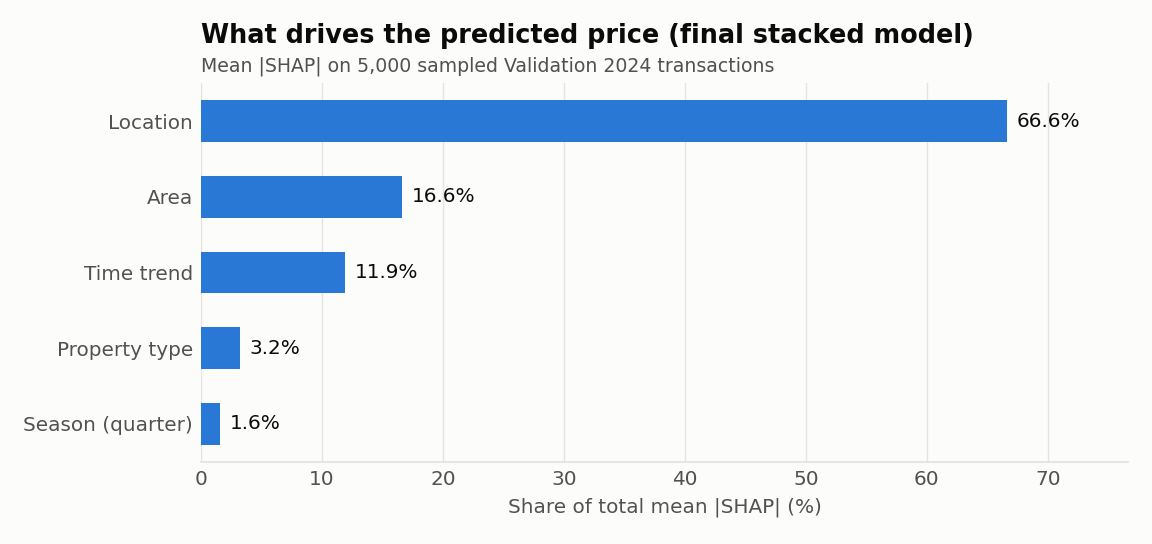

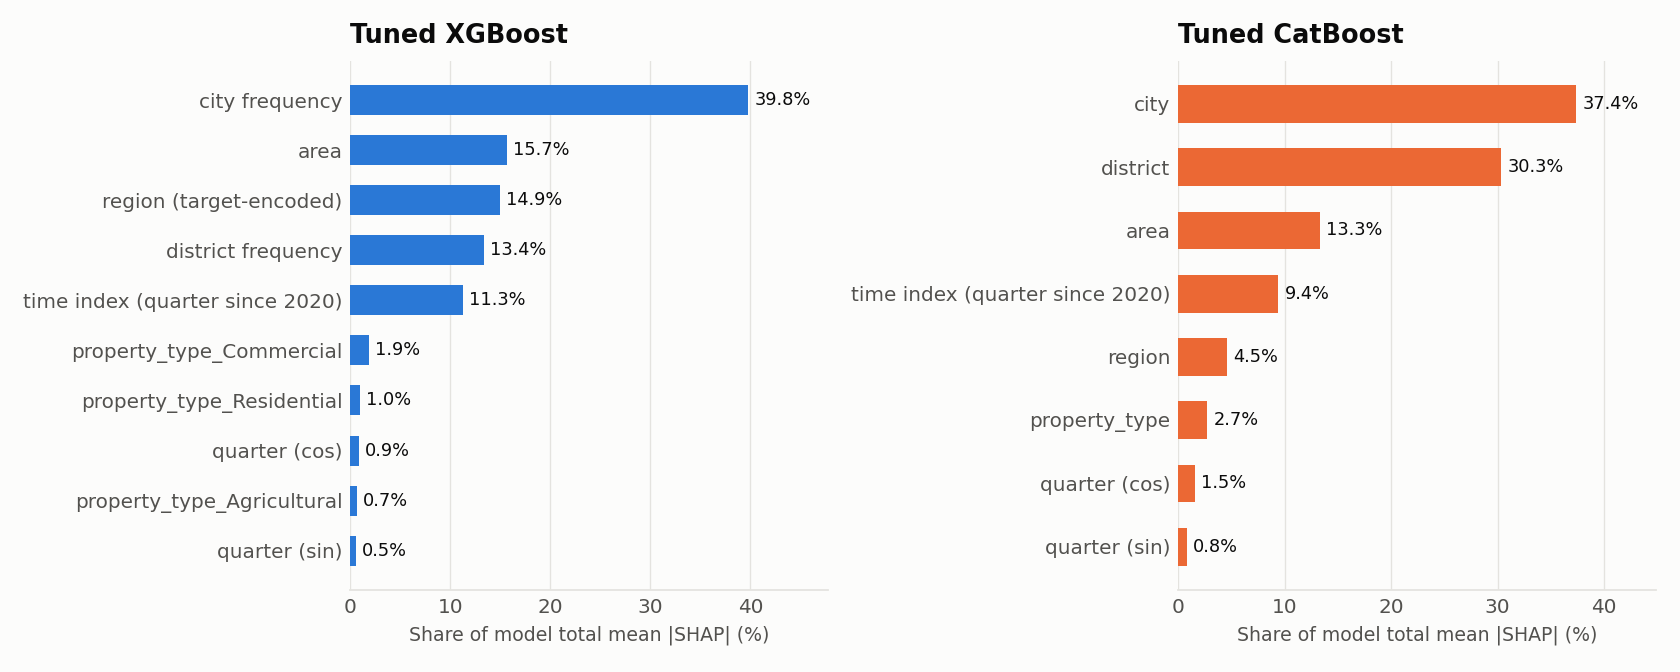

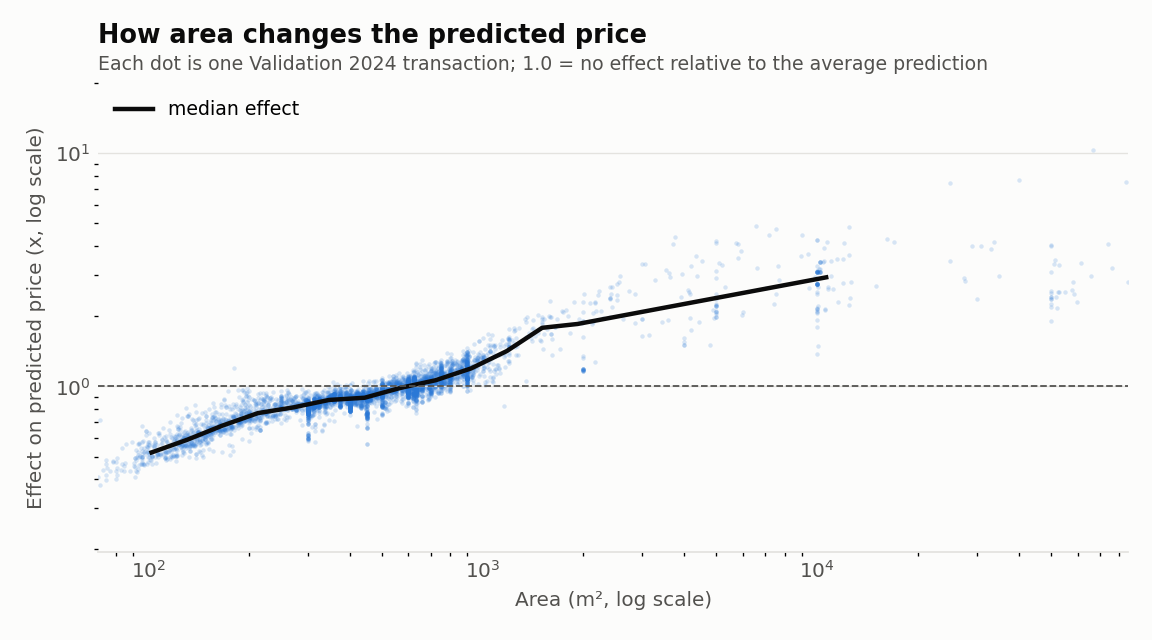

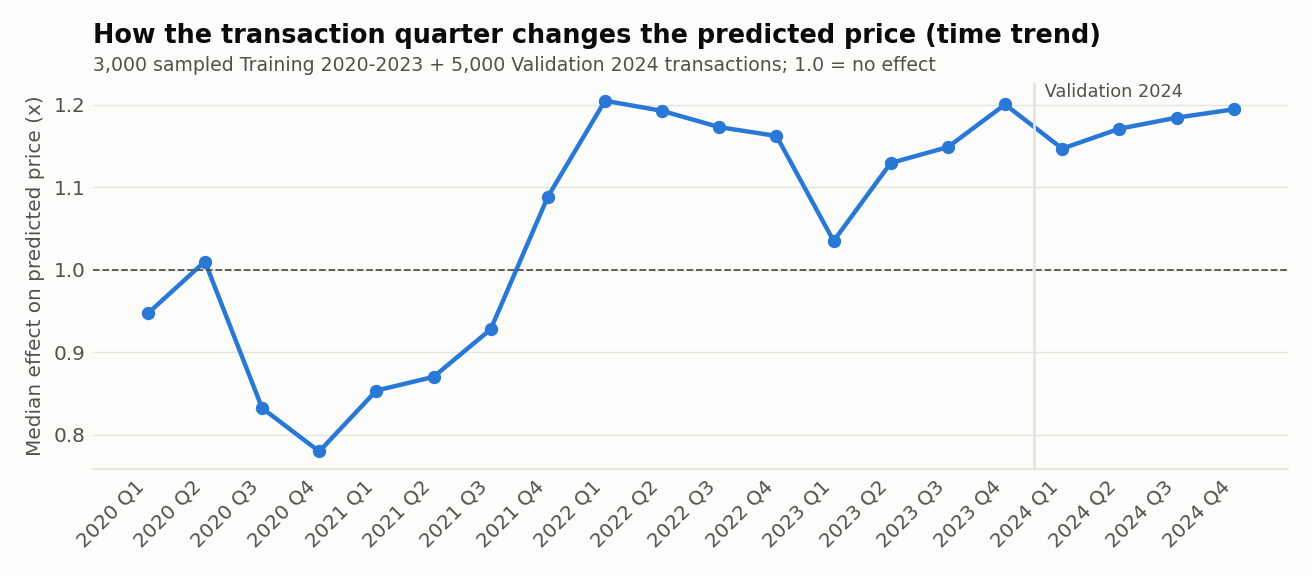

In [24]:
for name in ['characteristics', 'by_model', 'area_effect', 'time_effect']:
    display(Image(filename=str(TUNE / f'figures/feature_importance_{name}.png'), width=760))

### 7.9 Full tuning report

`outputs/tuning/reports/tuning_work_in_progress.md` (sections 3-12).

## 8. Limitations
- **Limited input information:** the data provide only area, time, location and property type; no building age, number of rooms or detailed property type. This caps the achievable accuracy more than the choice of model does.
- **A few very large transactions dominate the SAR-scale metrics:** rare, very expensive (mostly Commercial and Agricultural) deals drive RMSE and R² on the SAR scale, which makes them unstable; MAE is therefore the primary metric, with the median absolute error as support.
- **Tree models cannot extrapolate the time trend:** training ends in 2023, so 2024-2025 are predicted at the late-2023 price level (see the time-effect chart in 7.8). Periodic retraining or a market price index would address this.
- **Validation scores are slightly optimistic:** Validation 2024 was used for early stopping and, in the tuning stage, for choosing hyperparameters and the final model; Test 2025 gives the less biased estimate.
- **Limited search budget:** 44 tuning trials on a laptop CPU with one training seed per configuration; a larger search might find slightly better settings.

Details: `outputs/initial_models/reports/initial_models_report.md` and `outputs/tuning/reports/tuning_work_in_progress.md`.